# Chapter 18 - Clustering

*This notebook contains all the sample code in Chapter 18.*

## Outline

- [Introduction](#Introduction)
- [The k-means algorithm](#kmeans)
- [Other clustering approaches](#Other)
    - [Basic sequential algorithmic scheme](#BSAS)
    - [DBSCAN](#DBSCAN)
    - [HDBSCAN and OPTICS](#HDBSCAN)
    - [Spectral clustering](#Spectral)
- [Hierarchical clustering](#Hierarchical)
- [Model-based and probabilistic clustering](#GMM)
- [Comparison of clustering algorithms](#Comparison)
- [Evaluating clustering results](#Evaluating)
    - [Internal criteria](#Internal)
    - [External criteria](#External)
- [Vector quantization](#VQ)
- [Anomaly and novelty detection](#Anomaly)

## Introduction <a id="Introduction"></a>

Let $\mathcal{X}=\left\{\mathbf{x}_i\right\}_{i=1}^{N}$, with $\mathbf{x}_i\in\mathbb{R}^{L}$, be a set of $N$ unlabeled observations. **Cluster analysis** comprises methods that partition or organize these observations into subsets that are intended to reflect regularities in the data. Informally, points within the same *cluster* should be more similar to one another than to points belonging to different clusters.

The most common families are:
- **partitional methods**, such as $k$-means, which directly divide the observations into a prescribed number of non-overlapping clusters;
- **hierarchical methods**, which construct a hierarchy of nested clusters. Agglomerative methods proceed from individual samples to larger groups, whereas divisive methods repeatedly split an initial cluster containing all observations;
- **density-based methods**, such as DBSCAN, which identify connected regions having sufficiently high sample density and can explicitly label isolated observations as noise;
- **graph-based methods**, such as spectral clustering, which represent the observations through a similarity graph and partition that graph;
- **model-based methods**, such as Gaussian mixture models, which assume that the data are generated by a mixture of probability distributions.

## The k-means algorithm <a id="kmeans"></a>

The **$k$-means algorithm** partitions $N$ observations into a predefined number $k$ of nonempty clusters. Let $\mathcal{S}=\{S_1,S_2,\ldots,S_k\}$ denote a partition of the observations, and let $\boldsymbol{\mu}_j$ be the centroid of cluster $S_j$. The algorithm minimizes the *within-cluster sum of squares* (WCSS), also called **inertia**:
$$
\min_{\mathcal{S},\,\boldsymbol{\mu}_1,\ldots,\boldsymbol{\mu}_k} \sum_{j=1}^{k}\sum_{\mathbf{x}_i\in S_j} \left\|\mathbf{x}_i-\boldsymbol{\mu}_j\right\|_2^2.
$$
For a fixed partition, the centroid that minimizes the squared error is the arithmetic mean:
$$
\boldsymbol{\mu}_j=\frac{1}{|S_j|} \sum_{\mathbf{x}_i\in S_j}\mathbf{x}_i.
$$
The standard implementation, also called *Lloyd's algorithm*, alternates between two steps. Given centroids $\boldsymbol{\mu}_1^{(t)},\ldots,\boldsymbol{\mu}_k^{(t)}$ at iteration $t$:
1. **Assignment step**: assign each observation to the cluster with closest centroid:
$$
S_i^{(t)}=\arg\min_{j\in\{1,\ldots,k\}} \left\|\mathbf{x}_i-\boldsymbol{\mu}_j^{(t)}\right\|_2^2.
$$
2. **Update step**: recompute every centroid from the observations assigned to it:
$$
\boldsymbol{\mu}_j^{(t+1)} = \frac{1}{|S_j^{(t)}|} \sum_{i:c_i^{(t)}=j}\mathbf{x}_i.
$$
The following example generates three compact clusters, using the `make_blobs` function, and applies $k$-means after standardizing the features:

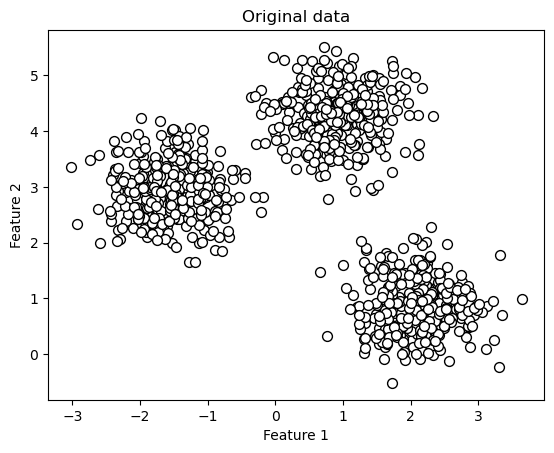

C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Impossibile trovare il file specificato
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\WKS\anaconda3\envs\mtf2\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\WKS\anaconda3\envs\mtf2\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\WKS\anaconda3\envs\mtf2\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
C:\Users

Inertia: 202.00031991829377


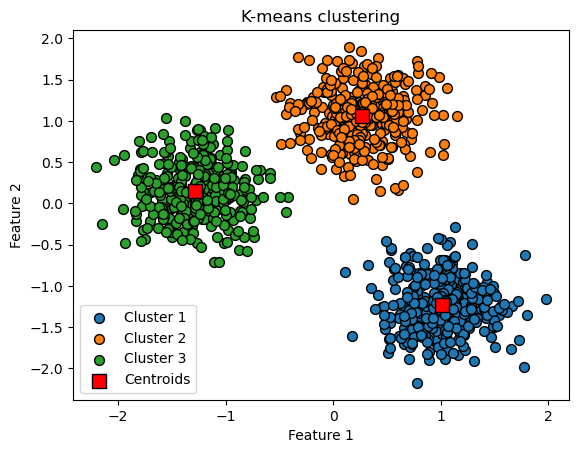

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_blobs, y_blobs = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=3,
    cluster_std=0.5,
    random_state=0,
)

plt.figure()
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c='white', marker='o', edgecolor='black', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original data")
plt.show()

pipe = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=3, n_init=10, random_state=0),
)
labels_km = pipe.fit_predict(X_blobs)

kmeans = pipe.named_steps["kmeans"]
centers_scaled = kmeans.cluster_centers_
print("Inertia:", kmeans.inertia_)

X_scaled = StandardScaler().fit_transform(X_blobs)

plt.figure()
plt.scatter(X_scaled[labels_km == 0, 0], X_scaled[labels_km == 0, 1], s=50, marker='o', edgecolor='black', label='Cluster 1')
plt.scatter(X_scaled[labels_km == 1, 0], X_scaled[labels_km == 1, 1], s=50, marker='o', edgecolor='black', label='Cluster 2')
plt.scatter(X_scaled[labels_km == 2, 0], X_scaled[labels_km == 2, 1], s=50, marker='o', edgecolor='black', label='Cluster 3')
plt.scatter(centers_scaled[:, 0], centers_scaled[:, 1], s=100, marker='s', c='red', edgecolor='black', label='Centroids')
plt.legend(scatterpoints=1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-means clustering")
plt.show()

A common diagnostic is the **elbow method**. The inertia is plotted as a function of $k$. Because inertia cannot increase when additional centroids are introduced, the objective always decreases. A useful value of $k$ may appear near a point beyond which the improvement becomes comparatively small.

C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known

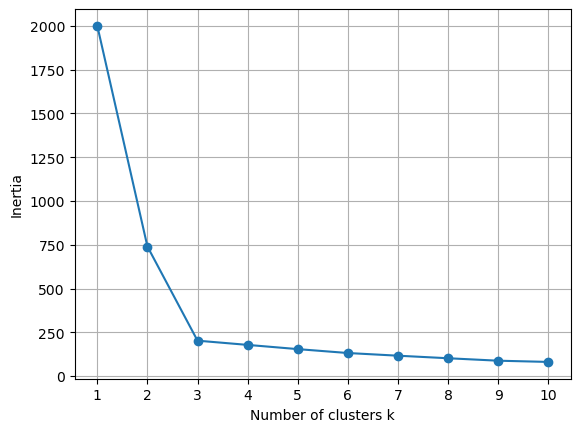

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_blobs)

inertias = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=0)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.plot(k_values, inertias, marker="o")
plt.grid()
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.show()

## Other clustering approaches <a id="Other"></a>


### Basic sequential algorithmic scheme <a id="BSAS"></a>

The **Basic Sequential Algorithmic Scheme** (BSAS) processes observations one at a time and does not require the final number of clusters to be specified directly. Let $\theta$ be a dissimilarity threshold and $K_{\max}$ the maximum permitted number of clusters. For each new observation, BSAS finds the nearest existing cluster. It creates a new cluster when the nearest distance exceeds $\theta$ and fewer than $K_{\max}$ clusters exist; otherwise, it assigns the observation to the nearest cluster and updates its representative.

A didactic implementation using Euclidean distance and centroid representatives is given below:

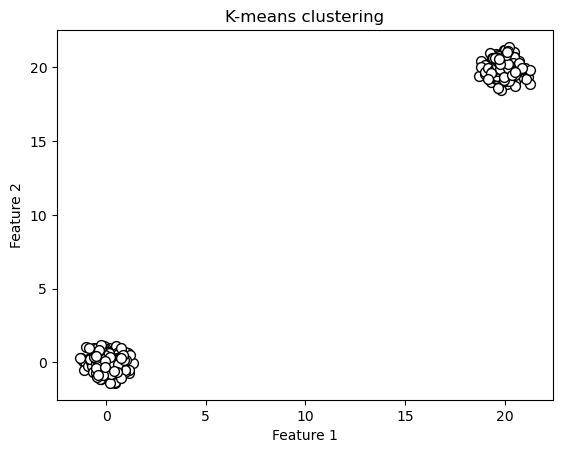

In [3]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt


class BSAS:
    """Basic Sequential Algorithmic Scheme with centroid updates."""

    def __init__(self, theta=1.0, max_clusters=10):
        self.theta = float(theta)
        self.max_clusters = int(max_clusters)

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)

        centroids = [X[0].copy()]
        sizes = [1]
        labels = np.zeros(X.shape[0], dtype=int)

        for i, x in enumerate(X[1:], start=1):
            distances = np.linalg.norm(np.vstack(centroids) - x, axis=1)
            nearest = int(np.argmin(distances))

            if (
                distances[nearest] > self.theta
                and len(centroids) < self.max_clusters
            ):
                centroids.append(x.copy())
                sizes.append(1)
                labels[i] = len(centroids) - 1
            else:
                labels[i] = nearest
                sizes[nearest] += 1
                centroids[nearest] += (
                    x - centroids[nearest]
                ) / sizes[nearest]

        self.cluster_centers_ = np.vstack(centroids)
        self.labels_ = labels
        self.cluster_sizes_ = np.asarray(sizes)
        self.n_clusters_ = len(centroids)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        distances = np.linalg.norm(
            X[:, None, :] - self.cluster_centers_[None, :, :],
            axis=2,
        )
        return np.argmin(distances, axis=1)

    def fit_predict(self, X, y=None):
        return self.fit(X, y).labels_


fixed_centers = [(0, 0), (20, 20)]

X_blobs, y_blobs = make_blobs(
    n_samples=500,
    n_features=2,
    centers=fixed_centers,
    center_box=(-5,25),
    cluster_std=0.5,
    random_state=0,
)

X, y = make_blobs(n_samples=500, n_features=2, centers=fixed_centers, cluster_std=0.5, center_box=(-5,25), shuffle=True, random_state=0)

plt.figure()
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c='white', edgecolors='black', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-means clustering")
plt.show()

BSAS is strongly order dependent. Shuffling the same observations can change both the assignments and the number of clusters. The threshold $\theta$ is also scale dependent, so preprocessing must be fixed before it is selected. A threshold-stability plot can be produced as follows:

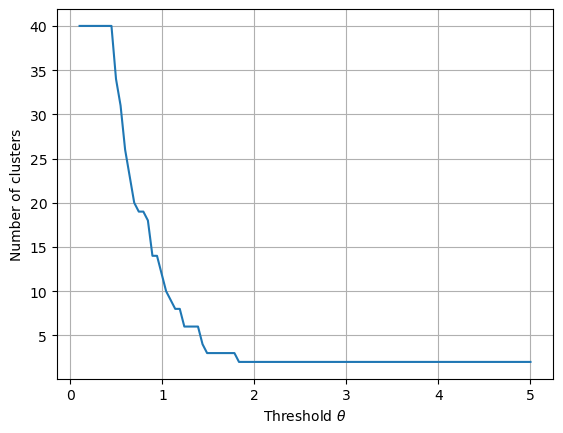

In [4]:
thresholds = np.linspace(0.1, 5.0, 100)
n_clusters = []

for theta in thresholds:
    model = BSAS(theta=theta, max_clusters=40)
    model.fit(X_blobs)
    n_clusters.append(model.n_clusters_)


plt.figure()
plt.plot(thresholds, n_clusters)
plt.xlabel(r"Threshold $\theta$")
plt.ylabel("Number of clusters")
plt.grid()
plt.show()

### DBSCAN <a id="DBSCAN"></a>

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) identifies clusters as connected dense regions. It uses two main parameters:
- $\varepsilon$, the radius of a neighborhood;
- `min_samples`, the minimum number of observations, including the point itself, required for a dense neighborhood.

An observation is a *core point* when its $\varepsilon$-neighborhood contains at least `min_samples` observations. A *border point* is not a core point but lies in the neighborhood of a core point. An observation that is neither a core nor a border point is labeled as noise. DBSCAN forms clusters by connecting core points whose neighborhoods overlap and then attaches reachable border points.

The algorithm does not require the number of clusters in advance, can detect nonconvex shapes, and explicitly identifies noise. Its main limitation is the assumption that one global density scale is adequate. It can struggle when different clusters have substantially different densities. Both $\varepsilon$ and `min_samples` depend on the feature scale and distance metric.

Labels: [0, 1]


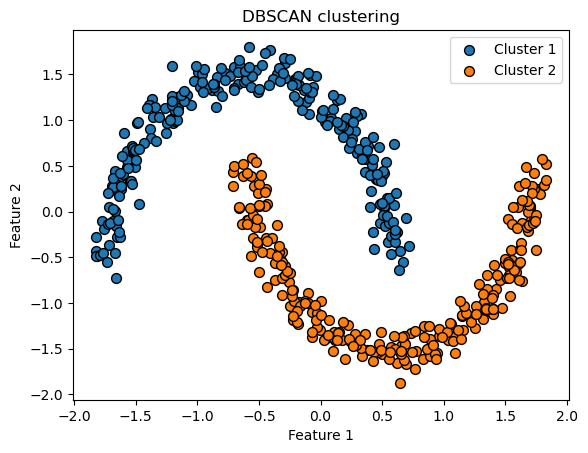

In [5]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.06,
    random_state=0,
)

model = make_pipeline(StandardScaler(), DBSCAN(eps=0.25, min_samples=5))
labels_db = model.fit_predict(X_moons)

# DBSCAN uses label -1 for noise observations.
print("Labels:", sorted(set(labels_db)))

X_scaled = StandardScaler().fit_transform(X_moons)

plt.figure()
plt.scatter(X_scaled[labels_db == 0, 0], X_scaled[labels_db == 0, 1], s=50, marker='o', edgecolor='black', label='Cluster 1')
plt.scatter(X_scaled[labels_db == 1, 0], X_scaled[labels_db == 1, 1], s=50, marker='o', edgecolor='black', label='Cluster 2')
plt.legend(scatterpoints=1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN clustering")
plt.show()

### HDBSCAN and OPTICS <a id="HDBSCAN"></a>

HDBSCAN extends density-based clustering by exploring several density levels and retaining groups that remain stable over a range of scales. It can therefore recover clusters having different densities more reliably than DBSCAN and requires no single global $\varepsilon$ value. Its most influential parameter is `min_cluster_size`. Scikit-learn provides a native implementation:

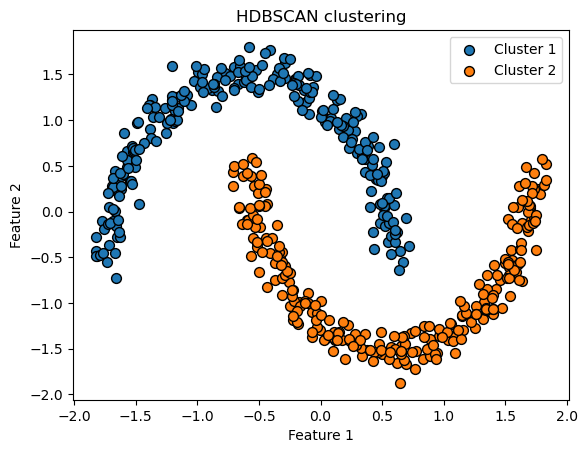

In [6]:
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler

hdb = HDBSCAN(min_cluster_size=20, min_samples=5)
labels_hdb = hdb.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_scaled[labels_db == 0, 0], X_scaled[labels_db == 0, 1], s=50, marker='o', edgecolor='black', label='Cluster 1')
plt.scatter(X_scaled[labels_db == 1, 0], X_scaled[labels_db == 1, 1], s=50, marker='o', edgecolor='black', label='Cluster 2')
plt.legend(scatterpoints=1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("HDBSCAN clustering")
plt.show()

OPTICS is another density-based approach that orders observations according to reachability and can extract cluster structure across several values of $\varepsilon$. These methods are particularly useful when a single DBSCAN density threshold is too restrictive.

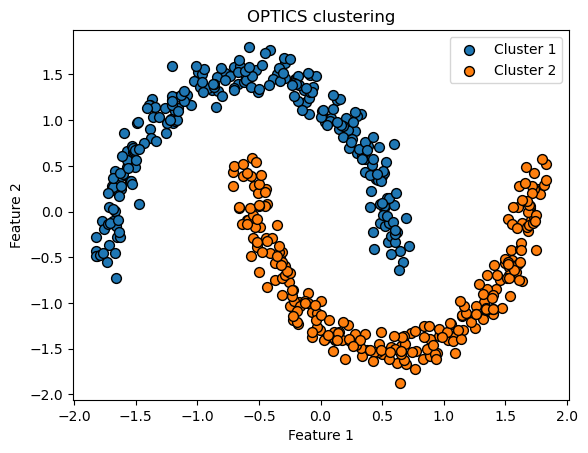

In [7]:
from sklearn.cluster import OPTICS

opt = OPTICS(min_samples=15)
labels_opt = opt.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_scaled[labels_db == 0, 0], X_scaled[labels_db == 0, 1], s=50, marker='o', edgecolor='black', label='Cluster 1')
plt.scatter(X_scaled[labels_db == 1, 0], X_scaled[labels_db == 1, 1], s=50, marker='o', edgecolor='black', label='Cluster 2')
plt.legend(scatterpoints=1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("OPTICS clustering")
plt.show()

### Spectral clustering <a id="Spectral"></a>

**Spectral clustering** represents observations as the vertices of a weighted graph. Let $\mathbf{S}$ be a symmetric affinity matrix, where $s_{ij}\geq 0$ quantifies the similarity between observations $\mathbf{x}_i$ and $\mathbf{x}_j$. The degree matrix $\mathbf{D}$ is diagonal with elements:
$$
d_{ii}=\sum_{j=1}^{N}s_{ij}.
$$
A commonly used ***normalized graph Laplacian*** is:
$$
\mathbf{L}_{\mathrm{sym}} = \mathbf{I}-\mathbf{D}^{-1/2}\mathbf{S}\mathbf{D}^{-1/2}.
$$
The eigenvectors associated with the smallest eigenvalues provide a low-dimensional representation in which a conventional algorithm such as $k$-means is applied. This construction can identify nonconvex groups that are not separable by centroid-based clustering.

C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\manifold\_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


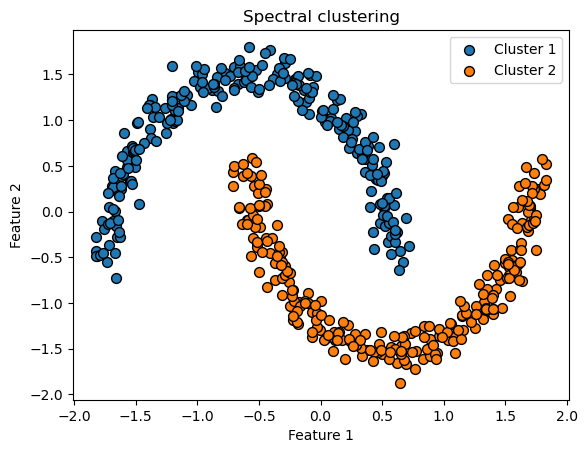

In [8]:
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_moons)

spectral = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=0,
)
labels_sc = spectral.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_scaled[labels_sc == 0, 0], X_scaled[labels_sc == 0, 1], s=50, marker='o', edgecolor='black', label='Cluster 1')
plt.scatter(X_scaled[labels_sc == 1, 0], X_scaled[labels_sc == 1, 1], s=50, marker='o', edgecolor='black', label='Cluster 2')
plt.legend(scatterpoints=1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Spectral clustering")
plt.show()

## Hierarchical clustering <a id="Hierarchical"></a>

**Hierarchical clustering** builds a nested sequence of groups. The two principal strategies are:
1. **agglomerative clustering**: every observation initially forms its own cluster, and the closest pair of clusters is repeatedly merged;
2. **divisive clustering**: all observations initially belong to one cluster, which is recursively divided.

Agglomerative methods require a dissimilarity between clusters, called a **linkage criterion**. For clusters $A$ and $B$, common choices are:
$$
d_{\mathrm{single}}(A,B) = \min_{\mathbf{x}\in A,\mathbf{z}\in B}d(\mathbf{x},\mathbf{z}),
$$
$$
d_{\mathrm{complete}}(A,B) =\max_{\mathbf{x}\in A,\mathbf{z}\in B}d(\mathbf{x},\mathbf{z}),
$$
$$
d_{\mathrm{average}}(A,B) =\frac{1}{|A||B|} \sum_{\mathbf{x}\in A}\sum_{\mathbf{z}\in B}d(\mathbf{x},\mathbf{z}).
$$
**Ward linkage** instead merges the pair producing the smallest increase in within-cluster squared error and is defined for Euclidean geometry.

Agglomerative clustering is available in Scikit-learn. The following example uses *Ward linkage* and requests two clusters:

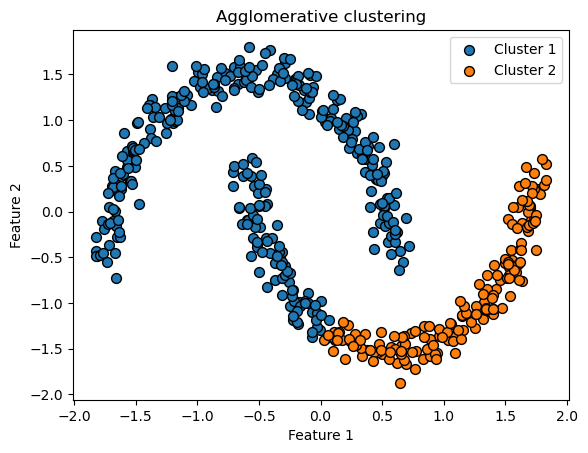

In [9]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt


X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.06,
    random_state=0,
)

X_scaled = StandardScaler().fit_transform(X_moons)

agg = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels_agg = agg.fit_predict(X_scaled)


plt.figure()
plt.scatter(X_scaled[labels_agg == 0, 0], X_scaled[labels_agg == 0, 1], s=50, marker='o', edgecolor='black', label='Cluster 1')
plt.scatter(X_scaled[labels_agg == 1, 0], X_scaled[labels_agg == 1, 1], s=50, marker='o', edgecolor='black', label='Cluster 2')
plt.legend(scatterpoints=1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative clustering")
plt.show()

## Model-based and probabilistic clustering <a id="GMM"></a>

**Model-based clustering** assumes that the observations are generated by a mixture of probability distributions. In a **Gaussian mixture model** (GMM), the density is:
$$
p(\mathbf{x}) = \sum_{j=1}^{k}\pi_j \,\mathcal{N}(\mathbf{x};\boldsymbol{\mu}_j,\boldsymbol{\Sigma}_j), \qquad \text{with} \quad \pi_j\geq 0,
\quad \sum_{j=1}^{k}\pi_j=1.
$$
The parameters are commonly estimated by the **expectation-maximization** (EM) algorithm. After fitting, the posterior membership probability of component $j$ is:
$$
\gamma_{ij} = P(z_i=j\mid\mathbf{x}_i) = \frac{\pi_j\mathcal{N}(\mathbf{x}_i;\boldsymbol{\mu}_j,\boldsymbol{\Sigma}_j)} {\sum_{r=1}^{k}\pi_r\mathcal{N}(\mathbf{x}_i;\boldsymbol{\mu}_r,\boldsymbol{\Sigma}_r)}.
$$
A hard clustering assigns $\mathbf{x}_i$ to the component having the largest posterior probability, whereas the full vector of responsibilities provides a soft clustering.

C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known

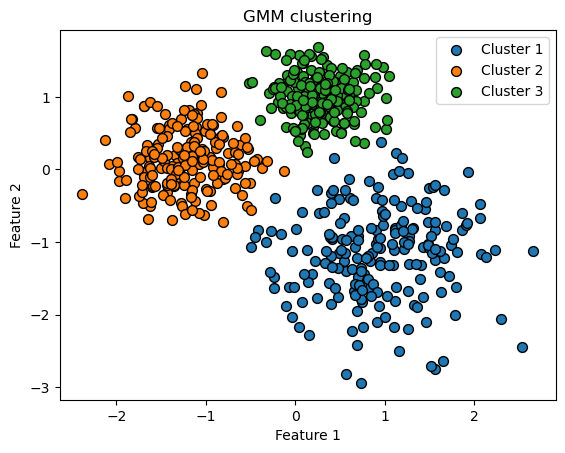

In [10]:
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


X_gmm, _ = make_blobs(
    n_samples=600,
    centers=3,
    cluster_std=[0.5, 1.0, 0.7],
    random_state=0,
)
X_gmm = StandardScaler().fit_transform(X_gmm)

gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    n_init=5,
    random_state=0,
)
labels_gmm = gmm.fit_predict(X_gmm)
probabilities = gmm.predict_proba(X_gmm)

X_scaled = StandardScaler().fit_transform(X_gmm)


plt.figure()
plt.scatter(X_scaled[labels_gmm == 0, 0], X_scaled[labels_gmm == 0, 1], s=50, marker='o', edgecolor='black', label='Cluster 1')
plt.scatter(X_scaled[labels_gmm == 1, 0], X_scaled[labels_gmm == 1, 1], s=50, marker='o', edgecolor='black', label='Cluster 2')
plt.scatter(X_scaled[labels_gmm == 2, 0], X_scaled[labels_gmm == 2, 1], s=50, marker='o', edgecolor='black', label='Cluster 3')
plt.legend(scatterpoints=1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("GMM clustering")
plt.show()

## Comparison of clustering algorithms <a id="Comparison"></a>

Compact Gaussian blobs satisfy the assumptions of several clustering methods, so they often produce similar partitions. Differences become clearer on nonconvex data. The following code compares four methods on two interleaving half circles:

C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


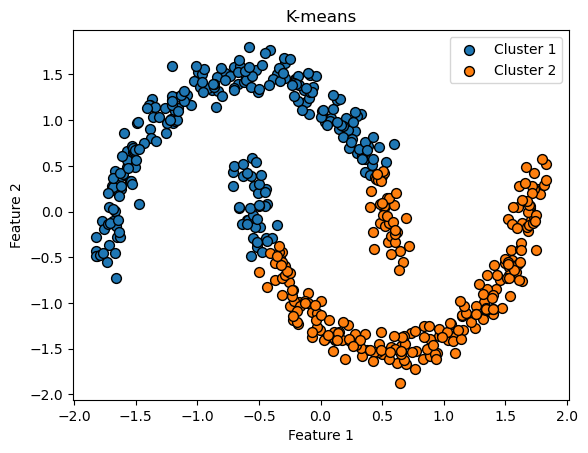

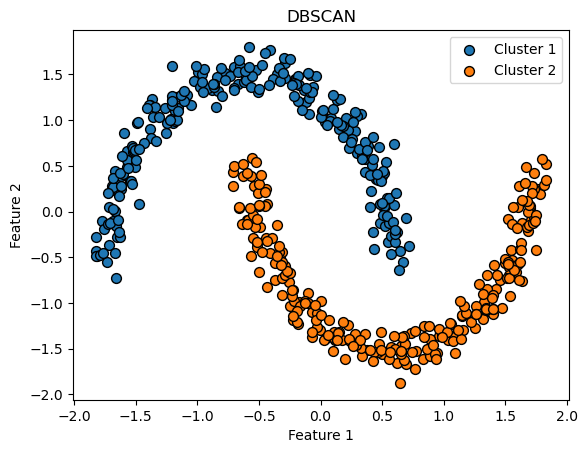

C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\manifold\_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


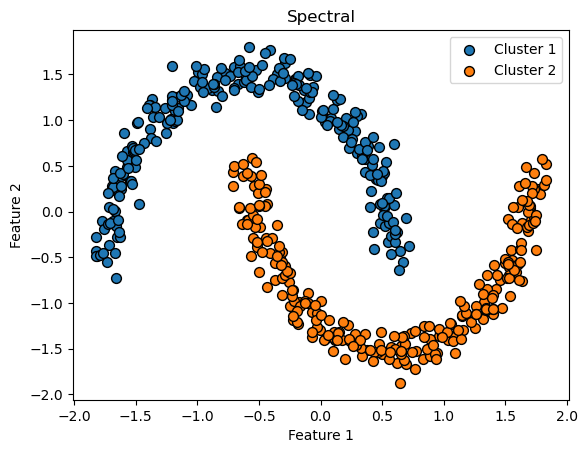

C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known

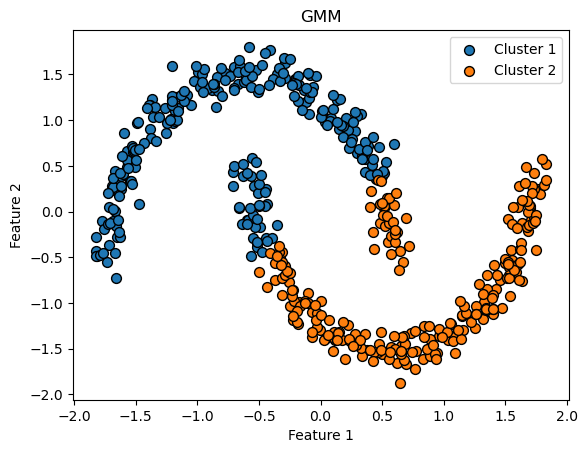

In [11]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans, SpectralClustering
from sklearn.datasets import make_moons
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

X, y_true = make_moons(
    n_samples=500,
    noise=0.06,
    random_state=0,
)
X_scaled = StandardScaler().fit_transform(X)

models = {
    "K-means": KMeans(n_clusters=2, n_init=10, random_state=0),
    "DBSCAN": DBSCAN(eps=0.25, min_samples=5),
    "Spectral": SpectralClustering(
        n_clusters=2, affinity="nearest_neighbors",
        n_neighbors=10, random_state=0,
    ),
    "GMM": GaussianMixture(n_components=2, n_init=5, random_state=0),
}

for name, model in models.items():
    labels = model.fit_predict(X_scaled)
    plt.figure()
    plt.scatter(X_scaled[labels == 0, 0], X_scaled[labels == 0, 1], s=50, marker='o', edgecolor='black', label='Cluster 1')
    plt.scatter(X_scaled[labels == 1, 0], X_scaled[labels == 1, 1], s=50, marker='o', edgecolor='black', label='Cluster 2')
    plt.legend(scatterpoints=1)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(name)
    plt.show()

This figure illustrates the typical outcome. $k$-means and a two-component Gaussian mixture tend to divide the observations into convex regions and therefore do not follow the crescent shapes. Properly tuned DBSCAN and spectral clustering can recover the two nonconvex groups. Their success is not automatic: DBSCAN depends on its density parameters, whereas spectral clustering depends on the affinity graph.

## Evaluating clustering results <a id="Evaluating"></a>

Clustering evaluation is more difficult than supervised evaluation because ground-truth labels are usually unavailable. Metrics can be divided into internal and external criteria.


### Internal criteria <a id="Internal"></a>

Internal criteria use only the observations and the estimated cluster labels. They quantify geometric properties such as compactness and separation, but they inevitably favor particular notions of a cluster.

The **silhouette** coefficient of observation $\mathbf{x}_i$ is based on:
- $a_i$, the average distance from $\mathbf{x}_i$ to the other observations in its own cluster;
- $b_i$, the smallest average distance from $\mathbf{x}_i$ to the observations in any other cluster.

It is defined as:
$$
s_i = \frac{b_i-a_i}{\max\{a_i,b_i\}}.
$$
The coefficient lies in $[-1,1]$. A value near $1$ indicates that the observation is substantially closer to its own cluster than to neighboring clusters. A value near zero indicates overlap or a boundary point, whereas a negative value suggests a potentially unsuitable assignment. The overall silhouette score is the mean of the sample coefficients.

C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Mean silhouette: 0.4951215346409402
Calinski-Harabasz: 696.9144256399844
Davies-Bouldin: 0.8078752391832899


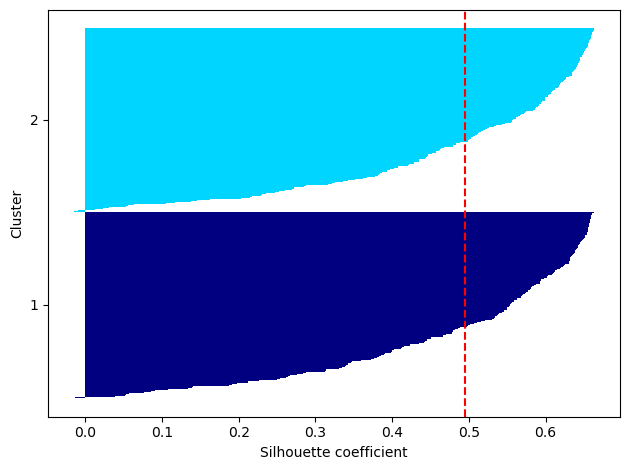

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)

X_scaled = StandardScaler().fit_transform(X_moons)

labels_eval = KMeans(
    n_clusters=2,
    n_init=10,
    random_state=0,
).fit_predict(X_scaled)


sample_silhouette = silhouette_samples(X_scaled, labels_eval)
mean_silhouette = silhouette_score(X_scaled, labels_eval)
ch_score = calinski_harabasz_score(X_scaled, labels_eval)
db_score = davies_bouldin_score(X_scaled, labels_eval)


print("Mean silhouette:", mean_silhouette)
print("Calinski-Harabasz:", ch_score)
print("Davies-Bouldin:", db_score)


# Plot silhouette
cluster_labels = np.unique(labels_eval)

from matplotlib import cm
y_ax_lower, y_ax_upper = 0, 0
yticks = []
for i, c in enumerate(cluster_labels):
    c_silhouette_vals = sample_silhouette[labels_eval == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / 3)
    plt.barh(range(y_ax_lower, y_ax_upper),c_silhouette_vals,height=1.0,edgecolor='none',color=color)
    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)

silhouette_avg = np.mean(sample_silhouette)
plt.axvline(silhouette_avg, color="red", linestyle="--")
plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')
plt.tight_layout()
plt.show()

### External criteria <a id="External"></a>

When reference labels are available for evaluation, external criteria compare two partitions without assuming that their numeric label identifiers match. Common examples are the **adjusted Rand index** (ARI) and **adjusted mutual information** (AMI). Both equal $1$ for identical partitions up to label permutation and are adjusted to reduce agreement expected by chance.

In [13]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score

labels_eval = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=0,
).fit_predict(X_scaled)

ari = adjusted_rand_score(y_moons, labels_eval)
ami = adjusted_mutual_info_score(y_moons, labels_eval)

print("Adjusted Rand index:", ari)
print("Adjusted mutual information:", ami)

C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\manifold\_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Adjusted Rand index: 1.0
Adjusted mutual information: 1.0


## Vector quantization <a id="VQ"></a>

Clustering can provide a compact representation of data through **vector quantization**. Let $\mathcal{C}=\{\mathbf{m}_1,\ldots,\mathbf{m}_k\}$ be a **codebook** of representative vectors. An input $\mathbf{x}$ is encoded by the index $i$ of its nearest **codeword**:
$$
i \equiv q(\mathbf{x}) = \arg\min_{j\in\{1,\ldots,k\}} \|\mathbf{x}-\mathbf{m}_j\|_2,
$$
and reconstructed (decoded) as:
$$
\widehat{\mathbf{x}} = \mathbf{m}_{q(\mathbf{x})}.
$$
Replacing observations by cluster representatives can compress data and remove small variations, but it can also eliminate important detail. The number of codewords controls the rate--distortion trade-off: a larger codebook requires more bits per index but usually produces a lower reconstruction error.

The following example reduces an RGB image to 64 representative colors:

C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\sklearn\cluster\_kmeans.py:1962: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 8192 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


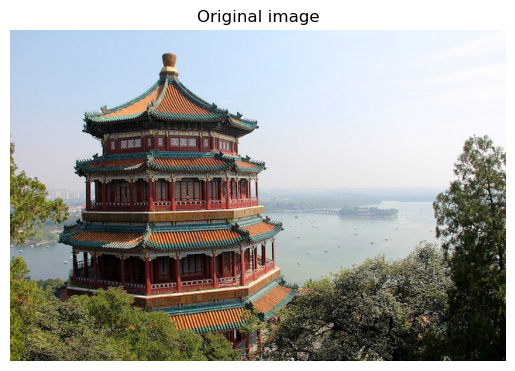

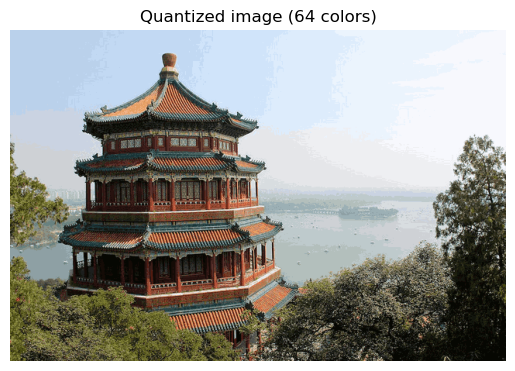

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.datasets import load_sample_image


n_colors = 64

image = load_sample_image("china.jpg")
image = np.asarray(image, dtype=np.float64) / 255.0

height, width, channels = image.shape
pixels = image.reshape(-1, channels)

rng = np.random.default_rng(0)
subset_size = min(10_000, pixels.shape[0])
indices = rng.choice(pixels.shape[0], size=subset_size, replace=False)


quantizer = MiniBatchKMeans(
    n_clusters=n_colors,
    n_init=3,
    batch_size=1024,
    random_state=0,
)
quantizer.fit(pixels[indices])

labels = quantizer.predict(pixels)
codebook = quantizer.cluster_centers_
quantized = codebook[labels].reshape(image.shape)


plt.figure()
plt.imshow(image)
plt.axis("off")
plt.title("Original image")

plt.figure()
plt.imshow(np.clip(quantized, 0.0, 1.0))
plt.axis("off")
plt.title(f"Quantized image ({n_colors} colors)")
plt.show()

## Anomaly and novelty detection <a id="Anomaly"></a>

Clustering searches for groups of similar observations, whereas **anomaly detection** aims to identify observations that differ significantly from the dominant data patterns. Anomalies may correspond to measurement errors, rare events, equipment faults, fraudulent transactions, or previously unseen operating conditions.

Two related settings should be distinguished:
- **outlier detection** assumes that the training data may already contain anomalous observations;
- **novelty detection** assumes that the training set contains only, or predominantly, normal observations and determines whether new samples conform to the learned normal pattern.

This distinction affects both model training and evaluation. In novelty detection, the model should be fitted only on representative normal data. The decision threshold must then be selected using separate validation data whenever labelled anomalies are available.

Common approaches include:
- **Isolation Forest**, which isolates unusual samples using random tree partitions;
- **Local Outlier Factor**, which compares the local density of a sample with those of its neighbours;
- **One-class SVM**, which estimates a boundary enclosing most normal observations.

[[494   6]
 [  6  24]]


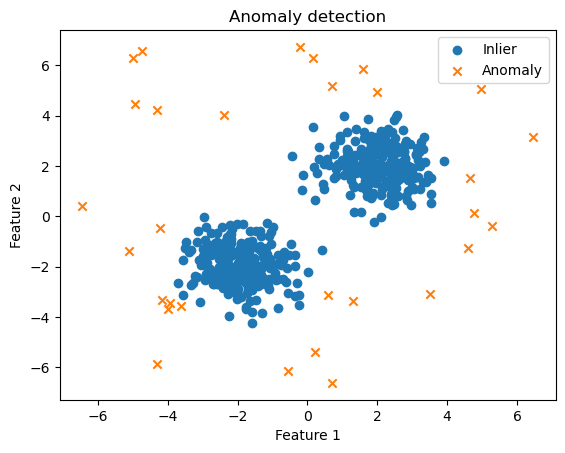

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix


rng = np.random.default_rng(1)

X_normal, _ = make_blobs(
    n_samples=500,
    centers=[(-2, -2), (2, 2)],
    cluster_std=0.8,
    random_state=1
)

X_anomaly = rng.uniform(low=-7.0, high=7.0, size=(30, 2))

X = np.vstack((X_normal, X_anomaly))

# Scikit-learn uses 1 for inliers and -1 for outliers.
y_true = np.concatenate((
    np.ones(len(X_normal), dtype=int),
    -np.ones(len(X_anomaly), dtype=int)
))

model = IsolationForest(
    contamination=len(X_anomaly) / len(X),
    random_state=1
)

y_pred = model.fit_predict(X)

print(confusion_matrix(y_true, y_pred, labels=[1, -1]))


plt.figure()
plt.scatter(
    X[y_pred == 1, 0],
    X[y_pred == 1, 1],
    label='Inlier'
)
plt.scatter(
    X[y_pred == -1, 0],
    X[y_pred == -1, 1],
    marker='x',
    label='Anomaly'
)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title("Anomaly detection")
plt.legend()
plt.show()

The `contamination` parameter controls the proportion of observations used to establish the decision threshold and should not be interpreted as a universally known anomaly rate. When labeled anomalies are available, the detector can be evaluated using precision, recall, the $F_1$-score, and the precision-recall curve. Accuracy is often unsuitable because anomalies are usually rare.

For **novelty detection** with a *one-class SVM*, the model can be trained only on normal observations:

[[474  26]
 [  3  27]]


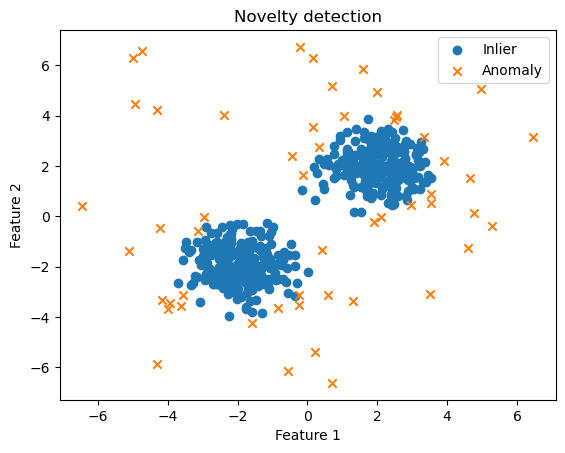

In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

novelty_detector = make_pipeline(
    StandardScaler(),
    OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
)

novelty_detector.fit(X_normal)
y_pred = novelty_detector.predict(X)

print(confusion_matrix(y_true, y_pred, labels=[1, -1]))

plt.scatter(
    X[y_pred == 1, 0],
    X[y_pred == 1, 1],
    label='Inlier'
)
plt.scatter(
    X[y_pred == -1, 0],
    X[y_pred == -1, 1],
    marker='x',
    label='Anomaly'
)
plt.title("Novelty detection")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()